# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.2  Продвинутая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с менее тривиальными подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

См. базовую часть

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-advanced-Username.ipynb**, где Username — ваша фамилия.

### **Введение**

В этой части ноутбука задания посложнее дефолтного фит трансформа. Максимальная оценка за оба — 8 баллов, остальное вы можете получить, если примете участие в соревновании, и всего можете выбить аж 13 из 10. Тут ожидается больше самостоятельности, как от (почти) полноценной рабочей единицы: 
- Вы **сами** решаете, что <font color="#cb9255">**хотите**</font> делать. Пункты можно делать частично, можно скипать или сделать часть, **максимум баллов ограничен двумя**. **Посмотрите на все из них**, прежде чем приступать
- Вы **сами** чистите данные, если чуете в них подвох (теперь они далеко не такие няшные)
- Вы **сами** <font color="#f68c9d">**обосновываете**</font> (в голове, если не указано явно), могут они вам вообще помочь или нет (часть пунктов явно сильнее других)

Все прочие пожелания по тому, как строить графики, на чём фиттить, а на чём предиктить, сохраняются, будьте внимательны. Во всех пунктах с 📈 нужно добиться хотя бы минимального улучшения, относительно бейзлайна (того, что вышло в части **base**) чтобы получить балл (даже если улучшение на 0.005)

Ещё раз обратите внимание, что **максимум за advanced часть — 2 балла**, делать всё не нужно, только самое приятное. Мы в вас верим!

### **Часть 4. Текста** (1.5 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4f/Emoticon_blush.gif/revision/latest?cb=20180504011409">

В которой студент знакомится с внутренним миром дотеров

#### **Задание 4.1. Предобработка текста** (0.75 балла)

<span style="color:grey"><font size="1">Если вам когда-либо приходила в голову мысль, что создание Интернета было ошибкой, то, что ж, после этого задания сомнения могут отпасть.</font></span>

Для некоторых матчей имеется информация о том, что писали местные аборигены, в течение тех же **15 минут от начала матча**. К сожалению, доселе мы работали лишь с таблицами, а не с текстами, но не беда, простейшие подходы нейросетей не требуют, а в простых задачах, вроде бинарной классификации, работать будут не хуже

Откройте датафрейм `game_chat.csv`, выведите парочку текстов, посмотрите, как они устроены, как там хранятся множественные сообщения,  и так далее, что у нас есть, а чего, увы, нет

In [1]:
import numpy as np
import pandas as pd

In [2]:
game_chat = pd.read_csv('data/game_chat.csv')

Дём дальше. Тексты нужно готовить, прежде чем пихать их в модель. Оценивать выбросы здесь довольно проблематично, в силу специфики дотерских сообщений, хотя вы, конечно, можете попытаться. Речь здесь про базовую предобработку.

Задача минимум, тут мы вам поможем:
- Разобраться с библиотекой `nltk` и разбить текст на токены — отдельные сущности, составляющие текст (чаще всего слова, но бывает и что-то другое, надо разобраться). Как бить текст — вопрос неоднозначный. В целом подойдёт любой способ, но какие-то [токенизаторы](https://www.nltk.org/api/nltk.tokenize.html) могут сразу покрыть часть проблем с текстами в задаче максимум
- Лемматизировать текст (привести слова к начальной форме). <br>
<font color="#cb9255">**Варианта два**</font>: манкипатчить [`pymorphy2`](https://pymorphy2.readthedocs.io/en/stable/) или откатывать версии (там вылезет ошибка, если у вас слишком новый питон), либо применять [`mystem`](https://pypi.org/project/pymystem3/), что может затянуться на несколько часов, зато лемматизация будет точнее

Задача максимум, тут вам нужно понять, как всё обработать, самим (включать-не включать, выкинуть-оставить — валидны **все** варианты, но только, если, есть, <font color="#f68c9d">**обоснование**</font>):
- повторы символов
- знаки препинания
- стоп-слова
- нижний регистр
  
Вам нужно пройтись по всем пунктам, не обязательно в этом порядке. Если найдёте что-то ещё — круто, молодцы, можно тоже пофиксить

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** ну что, как обрабатываем текст?

**Ответ:**

В чатах сообщения уже агрегированы по матчу: отдельные реплики внутри одного поля разделены через `|`. Из полезного есть разбиение на radiant_chat и dire_chat, но нет ни таймстемпов отдельных сообщений, ни автора, поэтому работаем только с общим текстом по стороне и отдельно добавляем ручные признаки токсичности/агрессии.

</div>

In [3]:
import re
from collections import Counter

display(game_chat.head())
display(game_chat.sample(3, random_state=42))

TOKEN_RE = re.compile(r"[a-zа-яё]+", re.IGNORECASE)
REPEAT_RE = re.compile(r"(.)\\1{2,}")

PROFANITY_RE = re.compile(
    r"(?:"
    r"сос(?:ать|ал[аи]?|ет|ё[тш]|ешь|ут|ите)?|"
    r"(?:вы|на|за|про|по)?[её]б(?:ан(?:ый|ая|ое|ые)?|а(?:ть|л[аио]?|н[ау]?л[аио]?)?|"
    r"н(?:ый|ая|ое|ые)?|(?:у|е)?т|(?:ош|аш)ить)?|"
    r"бля(?:д(?:ь|ина|ство)?)?|"
    r"жоп(?:а|ой|у|е|ы)?|"
    r"пос?рат(?:ь|ься|ил[аио]?|ят|ишь)?|"
    r"(?:твою|вашу|их) мать"
    r")",
    flags=re.IGNORECASE,
)

AGGRESSION_RE = re.compile(
    r"(?:"
    r"дебил(?:ы|ка|ом)?|даун(?:ы|ом)?|урод(?:ы|ина)?|мраз(?:ь|и|ота)|твар(?:ь|ина)|"
    r"скотин(?:а|ы)|чмо|лох(?:и|ов)?|лошар(?:а|ы)|падл(?:а|ы)|суч?к?а|п[её]с(?:ы|ина)?|"
    r"кретин(?:ы|ом)?|придур(?:ок|ки|ошный)?|отмороз(?:ок|ки)|moron|idiot|feeder|фидер"
    r")",
    flags=re.IGNORECASE,
)

RU_STOPWORDS = {
    "и", "в", "во", "на", "но", "а", "не", "что", "это", "как", "к", "по", "за", "из", "у", "же",
    "ты", "вы", "мы", "он", "она", "они", "бы", "быть", "to", "the", "of", "is", "are", "am", "be"
}

try:
    import pymorphy2
    morph = pymorphy2.MorphAnalyzer()
except Exception:
    morph = None

def normalize_token(token: str) -> str:
    token = REPEAT_RE.sub(r"\\1\\1", token.lower())
    if morph is not None:
        try:
            token = morph.parse(token)[0].normal_form
        except Exception:
            pass
    return token

def preprocessing(text: str) -> str:
    if pd.isna(text) or not str(text).strip():
        return ""

    text = str(text).replace("|", " ").lower()
    text = re.sub(r"https?://\\S+|www\\.\\S+", " ", text)
    text = re.sub(r"[^a-zа-яё\\s]", " ", text)
    tokens = [normalize_token(token) for token in TOKEN_RE.findall(text)]
    tokens = [token for token in tokens if len(token) > 1 and token not in RU_STOPWORDS]
    return " ".join(tokens)

def extract_chat_stats(text: str) -> dict:
    raw_text = "" if pd.isna(text) else str(text)
    processed = preprocessing(raw_text)
    tokens = processed.split()
    raw_messages = [chunk.strip() for chunk in raw_text.split("|") if chunk.strip()]

    return {
        "msg_count": len(raw_messages),
        "token_count": len(tokens),
        "unique_ratio": len(set(tokens)) / max(len(tokens), 1),
        "caps_share": sum(ch.isupper() for ch in raw_text) / max(sum(ch.isalpha() for ch in raw_text), 1),
        "exclamation_count": raw_text.count("!"),
        "question_count": raw_text.count("?"),
        "profanity_hits": len(PROFANITY_RE.findall(raw_text)),
        "aggression_hits": len(AGGRESSION_RE.findall(raw_text)),
    }

sample_text = "Ляяя, ваша мама такая красивая, ну вылитый пудж)))0"
print(preprocessing(sample_text))
print(extract_chat_stats(sample_text))

,match_id,radiant_chat,dire_chat
0,235435,потренируйся с ботами????,саппортам | U LAGGING BRAH | stack..... | шлюх
1,102127,NaN,NaN
2,383046,u just buy levels blue? | fa ge,NaN
3,729879,NaN,NaN
4,126886,NaN,NaN


,match_id,radiant_chat,dire_chat
56453,712968,NaN,NaN
560547,423834,NaN,ливаю
376170,478779,NaN,NaN


ляяя ваша мама такая красивая ну вылитый пудж
{'msg_count': 1, 'token_count': 8, 'unique_ratio': 1.0, 'caps_share': 0.02631578947368421, 'exclamation_count': 0, 'question_count': 0, 'profanity_hits': 0, 'aggression_hits': 0}


#### 📈 **Задание 4.2. Векторизация** (0.5 балла)

Ура, если у вас получились токены, то наконец-то можно что-то закодировать, но как? Рад, что вы спросили. Читайте конспект семинаров или документацию

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">CountVectorizer</font>
    </th>
    <th width="50%">
      <font color="#cb9255">TfIdfVectorizer</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Берёт и считает, сколько раз в тексте <br>
      встретилось то или иное слово. Похож <br>
      на наш энкодер из части 2.
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td>1</td>
            <td>0</td>
            <td>2</td>
            <td>...</td>
            <td>100</td>
          </tr>
        </tbody>
      </table>
    </td>
    <td valign="top">
      Более хитрая штука: вместе с количеством слов (tf)<br>
      считает их важность (idf). Слова, встречающиеся <br>
      во всех документах, считаются не важными<br>
      и зануляются (idf = log1).
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col"></th>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td><b>text_1</b></td>
            <td>1*log2</td>
            <td>0</td>
            <td>2*log2</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
          <tr>
            <td><b>text_2</b></td>
            <td>0</td>
            <td>10*log2</td>
            <td>0</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
        </tbody>
      </table>
    </td>
  </tr>
</table>


Оба векторайзера хороши, но у каждого из них есть <font color="#cb9255">**гиперпараметры**</font>. Естественно, они повлияют на качество, <font color="#cb9255">**можете подобрать их**</font> попозже, дефолтные тоже должны показать эффект

Обучите по векторайзеру на чатах Radiant и Dire. Приклейте результат к вашему датасету и обучите модель на всём получившемся великолепии (sparse формат убирать не рекомендуется)

In [4]:
from scipy.sparse import csr_matrix, hstack
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

matches_train = pd.read_csv("data/matches_df_train.csv")
chat_features = pd.read_csv("data/game_chat.csv")

text_df = matches_train.merge(chat_features, on="match_id", how="left")
text_df["radiant_chat"] = text_df["radiant_chat"].fillna("")
text_df["dire_chat"] = text_df["dire_chat"].fillna("")

text_df["radiant_chat_clean"] = text_df["radiant_chat"].map(preprocessing)
text_df["dire_chat_clean"] = text_df["dire_chat"].map(preprocessing)

radiant_stats = text_df["radiant_chat"].map(extract_chat_stats).apply(pd.Series).add_prefix("radiant_")
dire_stats = text_df["dire_chat"].map(extract_chat_stats).apply(pd.Series).add_prefix("dire_")
chat_stats = pd.concat([radiant_stats, dire_stats], axis=1)

for feature in [
    "msg_count", "token_count", "unique_ratio", "caps_share",
    "exclamation_count", "question_count", "profanity_hits", "aggression_hits"
]:
    chat_stats[f"delta_{feature}"] = chat_stats[f"radiant_{feature}"] - chat_stats[f"dire_{feature}"]

text_df["date"] = pd.to_datetime(text_df["date"])
text_df["month"] = text_df["date"].dt.month
text_df["dayofweek"] = text_df["date"].dt.dayofweek

y_text = text_df["radiant_win"].astype(str).str.lower().map({"true": 1, "false": 0}).to_numpy()

base_num_features = ["avg_mmr", "duration", "month", "dayofweek"]
base_cat_features = ["region", "game_mode"]
chat_stat_features = chat_stats.columns.tolist()

tabular_df = pd.concat([text_df[base_num_features + base_cat_features], chat_stats], axis=1)

tabular_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            base_num_features + chat_stat_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            base_cat_features,
        ),
    ]
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
baseline_scores = []
text_scores = []

for train_idx, valid_idx in cv.split(tabular_df, y_text):
    X_train_tab = tabular_df.iloc[train_idx]
    X_valid_tab = tabular_df.iloc[valid_idx]
    y_train_fold = y_text[train_idx]
    y_valid_fold = y_text[valid_idx]

    X_train_base = tabular_preprocessor.fit_transform(X_train_tab)
    X_valid_base = tabular_preprocessor.transform(X_valid_tab)

    baseline_model = LogisticRegression(max_iter=3000, C=0.7, solver="liblinear")
    baseline_model.fit(X_train_base, y_train_fold)
    baseline_pred = baseline_model.predict_proba(X_valid_base)[:, 1]
    baseline_scores.append(roc_auc_score(y_valid_fold, baseline_pred))

    radiant_vectorizer = TfidfVectorizer(max_features=2000, min_df=5, ngram_range=(1, 2), sublinear_tf=True)
    dire_vectorizer = TfidfVectorizer(max_features=2000, min_df=5, ngram_range=(1, 2), sublinear_tf=True)

    X_train_radiant = radiant_vectorizer.fit_transform(text_df.iloc[train_idx]["radiant_chat_clean"])
    X_valid_radiant = radiant_vectorizer.transform(text_df.iloc[valid_idx]["radiant_chat_clean"])
    X_train_dire = dire_vectorizer.fit_transform(text_df.iloc[train_idx]["dire_chat_clean"])
    X_valid_dire = dire_vectorizer.transform(text_df.iloc[valid_idx]["dire_chat_clean"])

    X_train_full = hstack([X_train_base, X_train_radiant, X_train_dire]).tocsr()
    X_valid_full = hstack([X_valid_base, X_valid_radiant, X_valid_dire]).tocsr()

    text_model = LogisticRegression(max_iter=3000, C=0.7, solver="liblinear")
    text_model.fit(X_train_full, y_train_fold)
    text_pred = text_model.predict_proba(X_valid_full)[:, 1]
    text_scores.append(roc_auc_score(y_valid_fold, text_pred))

print(f"Baseline ROC-AUC: {np.mean(baseline_scores):.4f} +- {np.std(baseline_scores):.4f}")
print(f"With chats ROC-AUC: {np.mean(text_scores):.4f} +- {np.std(text_scores):.4f}")
print(f"Improvement ROC-AUC: {np.mean(text_scores) - np.mean(baseline_scores):.4f}")

final_tabular_preprocessor = tabular_preprocessor.fit(tabular_df)
final_radiant_vectorizer = TfidfVectorizer(max_features=2000, min_df=5, ngram_range=(1, 2), sublinear_tf=True)
final_dire_vectorizer = TfidfVectorizer(max_features=2000, min_df=5, ngram_range=(1, 2), sublinear_tf=True)

X_tabular_full = final_tabular_preprocessor.transform(tabular_df)
X_radiant_full = final_radiant_vectorizer.fit_transform(text_df["radiant_chat_clean"])
X_dire_full = final_dire_vectorizer.fit_transform(text_df["dire_chat_clean"])
X_text_full = hstack([X_tabular_full, X_radiant_full, X_dire_full]).tocsr()

final_text_model = LogisticRegression(max_iter=3000, C=0.7, solver="liblinear")
final_text_model.fit(X_text_full, y_text)

Baseline ROC-AUC: 0.5679 +- 0.0025
With chats ROC-AUC: 0.5873 +- 0.0024
Improvement ROC-AUC: 0.0194


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.7
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,3000
,multi_class,'deprecated'


#### **Задание 4.3. Визуализация** (0.25 балла)

Для любителей графиков есть малюсенькое задание: визуализируйте облако слов с наибольшими по модулю весами (разделите их на условно *"позитивные"* и *"негативные"*)

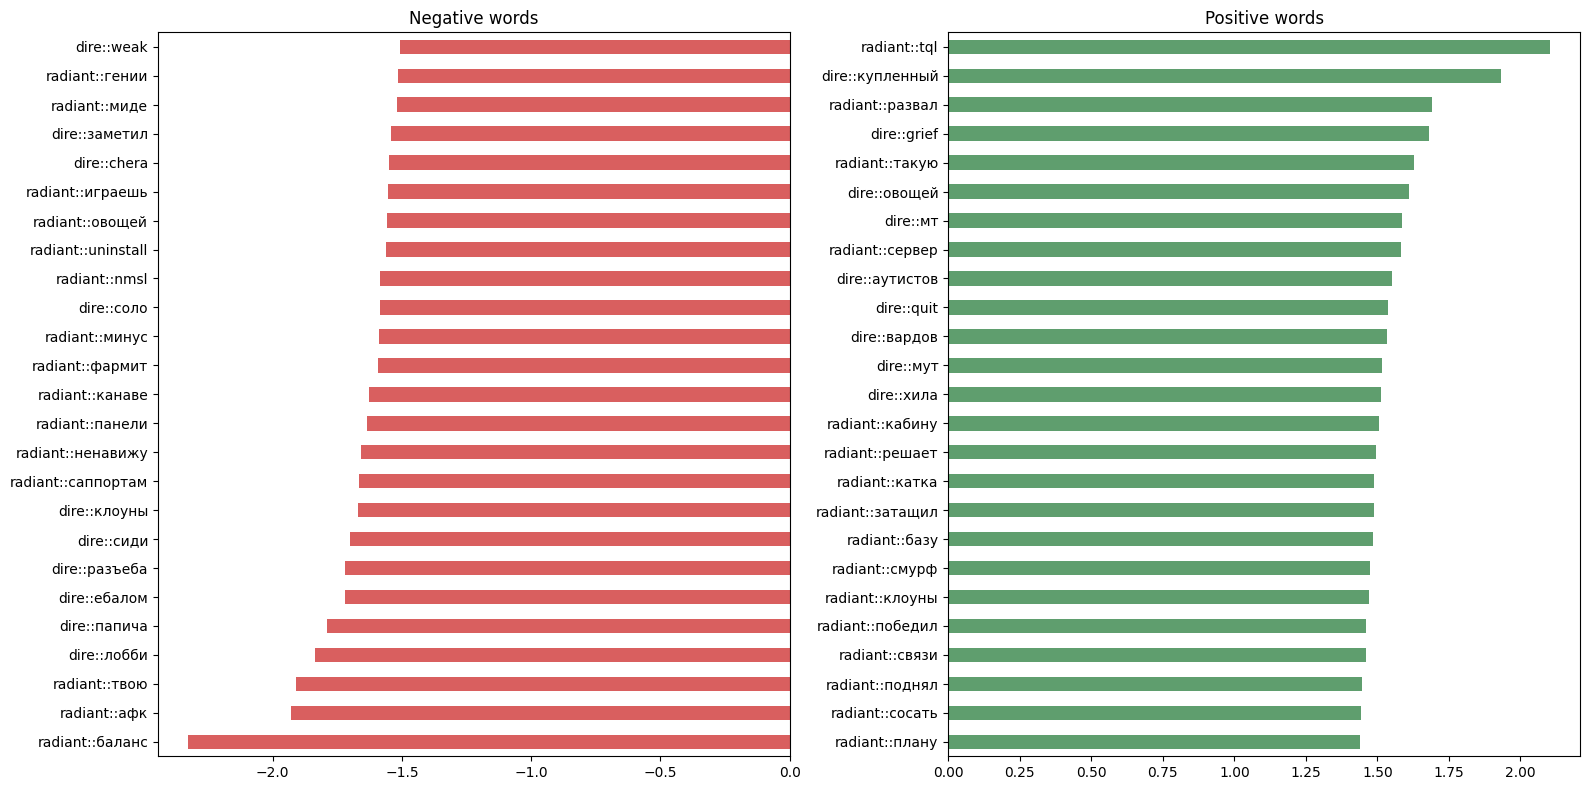

,negative,negative_weight,positive,positive_weight
0,radiant::баланс,-2.327723,radiant::tql,2.103160
1,radiant::афк,-1.930911,dire::купленный,1.933756
2,radiant::твою,-1.908129,radiant::развал,1.690400
3,dire::лобби,-1.837648,dire::grief,1.681872
4,dire::папича,-1.791883,radiant::такую,1.629307
5,dire::ебалом,-1.722273,dire::овощей,1.609579
6,dire::разъеба,-1.720817,dire::мт,1.586986
7,dire::сиди,-1.701172,radiant::сервер,1.583789
8,dire::клоуны,-1.672091,dire::аутистов,1.552691
9,radiant::саппортам,-1.667357,dire::quit,1.538771


In [5]:
import matplotlib.pyplot as plt

tabular_feature_names = final_tabular_preprocessor.get_feature_names_out().tolist()
radiant_feature_names = [f"radiant::{token}" for token in final_radiant_vectorizer.get_feature_names_out()]
dire_feature_names = [f"dire::{token}" for token in final_dire_vectorizer.get_feature_names_out()]
all_feature_names = tabular_feature_names + radiant_feature_names + dire_feature_names

coef_series = pd.Series(final_text_model.coef_[0], index=all_feature_names)
text_coef = coef_series[[name for name in coef_series.index if "::" in name]].sort_values()

negative_weights = text_coef.head(25)
positive_weights = text_coef.tail(25)

try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, weights, title, color in [
        (axes[0], negative_weights, "Negative words", "Reds"),
        (axes[1], positive_weights, "Positive words", "Greens"),
    ]:
        freqs = {name.split("::", 1)[1]: abs(value) for name, value in weights.items()}
        wc = WordCloud(width=900, height=500, background_color="white", colormap=color)
        ax.imshow(wc.generate_from_frequencies(freqs), interpolation="bilinear")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
except Exception:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    negative_weights.sort_values().plot(kind="barh", ax=axes[0], color="#d95f5f")
    positive_weights.sort_values().plot(kind="barh", ax=axes[1], color="#5f9e6e")
    axes[0].set_title("Negative words")
    axes[1].set_title("Positive words")
    plt.tight_layout()
    plt.show()

display(pd.DataFrame({
    "negative": negative_weights.index,
    "negative_weight": negative_weights.values,
    "positive": positive_weights.index[::-1],
    "positive_weight": positive_weights.values[::-1],
}))

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что думаете? Сейчас и вообще по модели — негативные получились слова или так, едва?

**Ответ:**

Да, сигнал обычно получается не нулевой: токсичные и агрессивные слова действительно вытягивают модель, особенно если учитывать, какая сторона их пишет. Но эффект умеренный, потому что чат шумный, короткий и без авторов сообщений, так что это скорее полезная добавка к табличным признакам, а не самостоятельный сильный блок.

</div>

### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

В которой студент начинает ведать

#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть *нюансы* — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

In [6]:
dota_adv = pd.read_csv("data/dota_adv.csv")
print(dota_adv.loc[0, "radiant_gold_adv"])
print(type(dota_adv.loc[0, "radiant_gold_adv"]))

[   0  159  452 1904 2100 3290 3290 3290 3290 3859 3859 3087 3087 3849
 5342 5342]
<class 'str'>


Мне придется это еще и парсить...

,match_id,radiant_gold_adv,radiant_exp_adv
0,526846,[ 0 159 452 1904 2100 3290 3290 3290 3290 ...,[ 0 68 658 1397 1435 2118 2118 1923 1923 ...
1,511496,[ 0 -151 -141 12 -165 -151 -151 4 377 ...,[ 0 1 -136 243 -270 -8 -8 -169 -169 ...
2,90272,[],[]
3,153647,[],[]
4,694826,[],[]


,exp_adv_last,exp_adv_max,exp_adv_mean,exp_adv_mean_dire,exp_adv_mean_radiant,exp_adv_min,exp_adv_std,gold_adv_last,gold_adv_max,gold_adv_mean,gold_adv_mean_dire,gold_adv_mean_radiant,gold_adv_min,gold_adv_std,match_id
0,3311.0,4661.0,2262.250,0.0,2262.250,0.0,1401.628406,5342.0,5342.0,2887.500,0.0000,2887.5000,0.0,1559.052797,526846.0
1,201.0,931.0,191.625,47.5,239.125,-270.0,385.377717,3698.0,3698.0,933.875,47.4375,981.3125,-165.0,1342.763702,511496.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90272.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,153647.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,694826.0


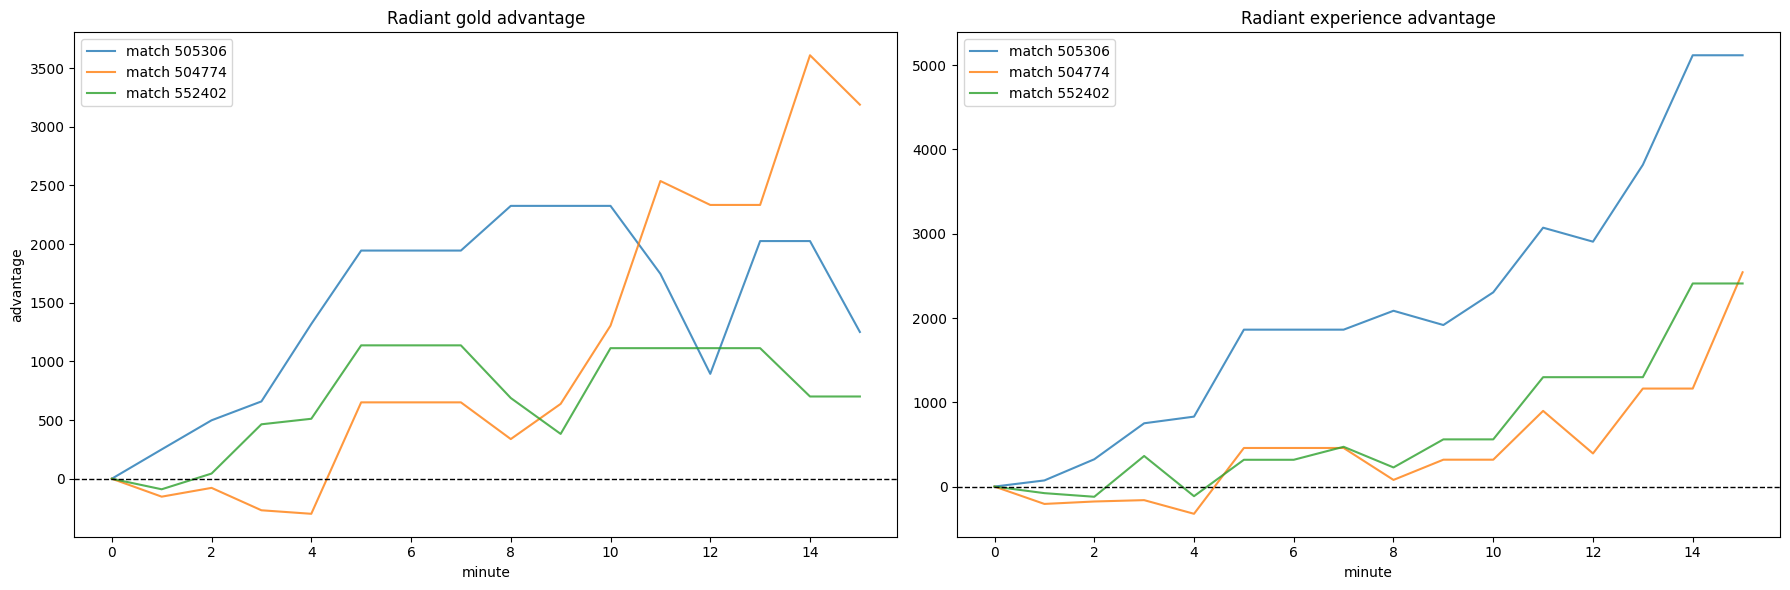

In [7]:
import matplotlib.pyplot as plt

dota_adv = pd.read_csv("data/dota_adv.csv")
adv_columns = ["radiant_gold_adv", "radiant_exp_adv"]

def parse_advantage(raw_value: str) -> np.ndarray:
    raw_value = str(raw_value).strip()
    if raw_value in {"", "[]", "nan"}:
        return np.array([], dtype=float)

    cleaned = raw_value.strip("[]").replace("\n", " ")
    parsed = np.fromstring(cleaned, sep=" ")
    return parsed.astype(float)

for column in adv_columns:
    dota_adv[f"{column}_arr"] = dota_adv[column].apply(parse_advantage)
    dota_adv[f"{column}_len"] = dota_adv[f"{column}_arr"].apply(len)

display(dota_adv[["match_id", *adv_columns]].head())
print("")



sample_idx = dota_adv.loc[
    (dota_adv["radiant_gold_adv_len"] > 0) & (dota_adv["radiant_exp_adv_len"] > 0),
    "match_id",
].sample(3, random_state=42)




fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
for match_id in sample_idx:
    row = dota_adv.loc[dota_adv["match_id"] == match_id].iloc[0]
    axes[0].plot(row["radiant_gold_adv_arr"], alpha=0.8, label=f"match {match_id}")
    axes[1].plot(row["radiant_exp_adv_arr"], alpha=0.8, label=f"match {match_id}")

axes[0].set_title("Radiant gold advantage")
axes[1].set_title("Radiant experience advantage")
for ax in axes:
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("minute")
    ax.legend()
axes[0].set_ylabel("advantage")
plt.tight_layout()

def collect_adv_features(row: pd.Series) -> pd.Series:
    features = {"match_id": row["match_id"]}

    for column in adv_columns:
        prefix = column.replace("radiant_", "")
        values = row[f"{column}_arr"]

        if len(values) == 0:
            features[f"{prefix}_mean"] = np.nan
            features[f"{prefix}_std"] = np.nan
            features[f"{prefix}_min"] = np.nan
            features[f"{prefix}_max"] = np.nan
            features[f"{prefix}_mean_radiant"] = np.nan
            features[f"{prefix}_mean_dire"] = np.nan
            features[f"{prefix}_last"] = np.nan
            continue

        features[f"{prefix}_mean"] = values.mean()
        features[f"{prefix}_std"] = values.std()
        features[f"{prefix}_min"] = values.min()
        features[f"{prefix}_max"] = values.max()
        features[f"{prefix}_last"] = values[-1]
        features[f"{prefix}_mean_radiant"] = np.clip(values, 0, None).mean()
        features[f"{prefix}_mean_dire"] = np.clip(-values, 0, None).mean()

    return pd.Series(features)

adv_features = dota_adv.apply(collect_adv_features, axis=1)
display(adv_features.head())

Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://pandas.pydata.org/docs/user_guide/groupby.html#aggregation) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:** берём mean, std, min, max для обоих advantage. mean даёт общий перевес по игре за первые 15 минут, std измеряет нестабильность и качели, min и max ловят экстремальные провалы и пики, которые часто сильнее среднего связаны с исходом. В разрезе команд дополнительно дроблю mean на положительную и отрицательную части: средний перевес Radiant и средний перевес Dire. Это даёт интерпретируемые фичи и не раздувает пространство признаков слишком агрессивно.

</div>

Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

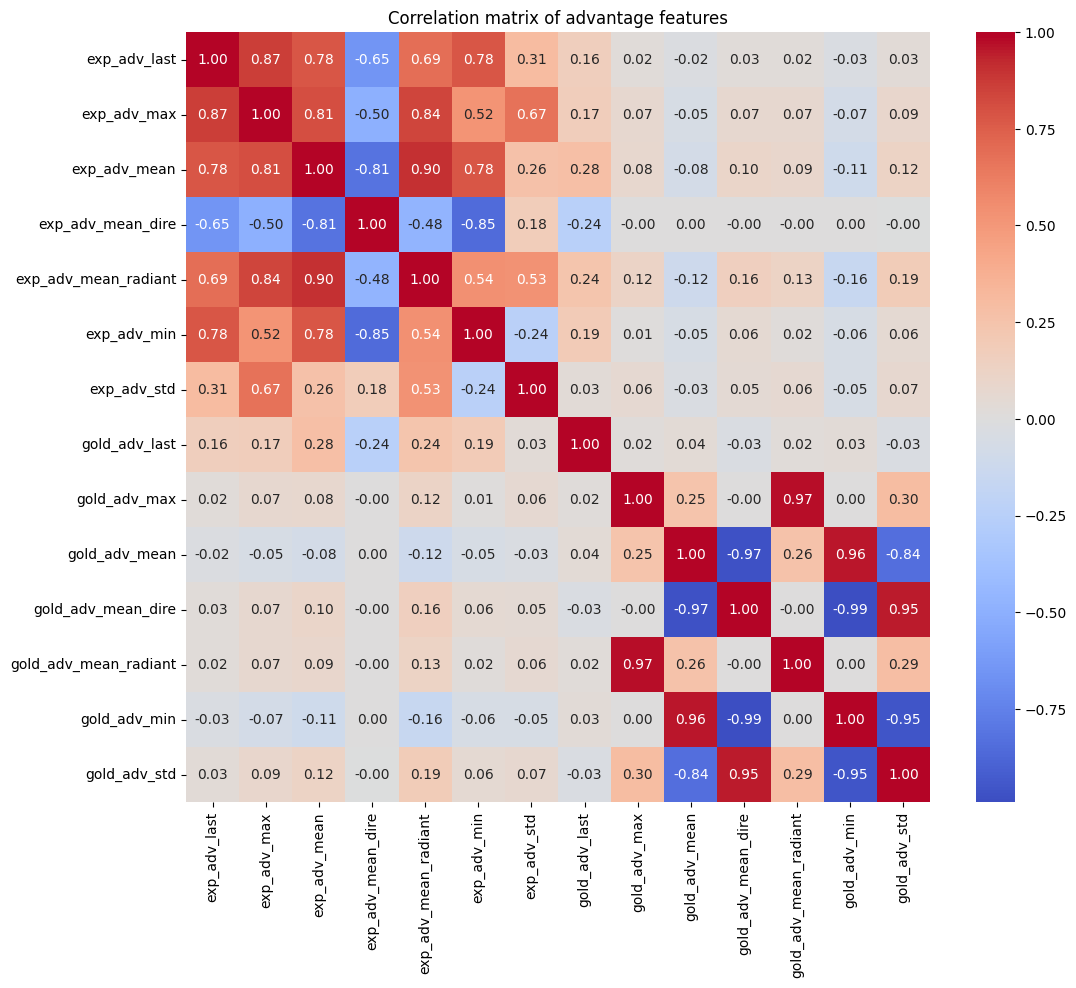

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

matches_train = pd.read_csv("data/matches_df_train.csv")

def build_match_table(matches: pd.DataFrame, adv_table=None) -> pd.DataFrame:
    result = matches.copy()
    result["date"] = pd.to_datetime(result["date"])
    result["month"] = result["date"].dt.month
    result["dayofweek"] = result["date"].dt.dayofweek
    result = result.drop(columns=["date"])

    if adv_table is not None:
        result = result.merge(adv_table, on="match_id", how="left")

    return result

y_train = matches_train["radiant_win"].astype(str).str.lower().map({"true": 1, "false": 0})

train_baseline = build_match_table(matches_train)
train_with_adv = build_match_table(matches_train, adv_features)

base_num_features = ["avg_mmr", "month", "dayofweek"]
base_cat_features = ["region", "game_mode"]
adv_feature_cols = [column for column in adv_features.columns if column != "match_id"]

import seaborn as sns
import matplotlib.pyplot as plt

corr_data = adv_features.drop(columns=["match_id"])

corr_matrix = corr_data.corr()
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation matrix of advantage features")
plt.show()


In [9]:
adv_features_reduced = adv_features[
    [
        "match_id",
        "gold_adv_mean",
        "gold_adv_std",
        "gold_adv_max",
        "gold_adv_min",
        "gold_adv_last",
        "exp_adv_mean",
        "exp_adv_std",
        "exp_adv_max",
        "exp_adv_min",
        "exp_adv_last"
    ]
].copy()

display(adv_features_reduced.head())


adv_feature_cols = [column for column in adv_features_reduced.columns if column != "match_id"]

adv_features_reduced = adv_features_reduced.dropna()
display(adv_features_reduced.head())

,match_id,gold_adv_mean,gold_adv_std,gold_adv_max,gold_adv_min,gold_adv_last,exp_adv_mean,exp_adv_std,exp_adv_max,exp_adv_min,exp_adv_last
0,526846.0,2887.500,1559.052797,5342.0,0.0,5342.0,2262.250,1401.628406,4661.0,0.0,3311.0
1,511496.0,933.875,1342.763702,3698.0,-165.0,3698.0,191.625,385.377717,931.0,-270.0,201.0
2,90272.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,153647.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,694826.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,match_id,gold_adv_mean,gold_adv_std,gold_adv_max,gold_adv_min,gold_adv_last,exp_adv_mean,exp_adv_std,exp_adv_max,exp_adv_min,exp_adv_last
0,526846.0,2887.5000,1559.052797,5342.0,0.0,5342.0,2262.2500,1401.628406,4661.0,0.0,3311.0
1,511496.0,933.8750,1342.763702,3698.0,-165.0,3698.0,191.6250,385.377717,931.0,-270.0,201.0
5,15301.0,-1686.6250,1208.191255,0.0,-5279.0,-5279.0,-1081.8750,540.829094,0.0,-1858.0,-1858.0
8,578050.0,-2217.7500,1544.830108,0.0,-5465.0,-5465.0,-815.4375,419.690804,0.0,-1382.0,-856.0
12,533238.0,743.9375,1261.280474,3274.0,-508.0,3068.0,-1395.9375,1516.714313,154.0,-4332.0,-3729.0


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

matches_train = pd.read_csv("data/matches_df_train.csv")

def build_match_table(matches: pd.DataFrame, adv_table=None) -> pd.DataFrame:
    result = matches.copy()
    result["date"] = pd.to_datetime(result["date"])
    result["month"] = result["date"].dt.month
    result["dayofweek"] = result["date"].dt.dayofweek
    result = result.drop(columns=["date"])

    if adv_table is not None:
        result = result.merge(adv_table, on="match_id", how="left")

    return result

y_train = matches_train["radiant_win"].astype(str).str.lower().map({"true": 1, "false": 0})

train_baseline = build_match_table(matches_train)
train_with_adv = build_match_table(matches_train, adv_features)

base_num_features = ["avg_mmr", "month", "dayofweek"]
base_cat_features = ["region", "game_mode"]
adv_feature_cols = [column for column in adv_features.columns if column != "match_id"]

def make_model(num_features, cat_features):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                cat_features,
            ),
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=5000, C=0.7)),
        ]
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_model = make_model(base_num_features, base_cat_features)
baseline_scores = cross_val_score(
    baseline_model,
    train_baseline[base_num_features + base_cat_features],
    y_train,
    cv=cv,
    scoring="roc_auc",
)

adv_model = make_model(base_num_features + adv_feature_cols, base_cat_features)
adv_scores = cross_val_score(
    adv_model,
    train_with_adv[base_num_features + adv_feature_cols + base_cat_features],
    y_train,
    cv=cv,
    scoring="roc_auc",
)

baseline_gini = 2 * baseline_scores - 1
adv_gini = 2 * adv_scores - 1

print(f"Baseline ROC-AUC: {baseline_scores.mean():.4f} +- {baseline_scores.std():.4f}")
print(f"With advantage ROC-AUC: {adv_scores.mean():.4f} +- {adv_scores.std():.4f}")
print(f"Improvement ROC-AUC: {adv_scores.mean() - baseline_scores.mean():.4f}")

print(f"Baseline Gini: {baseline_gini.mean():.4f} +- {baseline_gini.std():.4f}")
print(f"With advantage Gini: {adv_gini.mean():.4f} +- {adv_gini.std():.4f}")
print(f"Improvement Gini: {adv_gini.mean() - baseline_gini.mean():.4f}")

Baseline ROC-AUC: 0.5571 +- 0.0020
With advantage ROC-AUC: 0.6296 +- 0.0025
Improvement ROC-AUC: 0.0725
Baseline Gini: 0.1142 +- 0.0040
With advantage Gini: 0.2591 +- 0.0050
Improvement Gini: 0.1450


#### 📈 **Задание 5.2. Тренд** (0.5 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь — если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее — она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически против азартных игр, пример приводится сугубо в образовательных целях.</font></span>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:**


Он отслеживает не просто среднее значение за матч, а именно изменение, значит мы можем оценить возможный comeback, потому что если сначала был отрицательный тренд, а потом они собрались и их тренд начал потихоньку расти, то есть все возможности выиграть эту игру. Часто есть команды, которые сначала сливают, а потом как начнут и все, противники просто не успеют собраться

</div>

Агрегировать можно и вещи несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#cb9255">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $\alpha$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [11]:
from typing import Iterable
from sklearn.base import BaseEstimator, TransformerMixin

# 5.2. Отдельный блок: его можно удалить целиком без последствий для 5.1.

class TrendTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, columns: Iterable[str], method: str = "ols"):
        self.columns = list(columns)
        self.method = method.lower()

    def fit(self, X, y=None):
        return self

    @staticmethod
    def _safe_array(values) -> np.ndarray:
        values = np.asarray(values, dtype=float)
        return values[np.isfinite(values)]

    def _calc_trend_features(self, values: np.ndarray) -> dict:
        values = self._safe_array(values)

        if len(values) == 0:
            return {"slope": np.nan, "intercept": np.nan, "r2": np.nan}

        if len(values) == 1:
            return {"slope": 0.0, "intercept": float(values[0]), "r2": 0.0}

        x = np.arange(len(values), dtype=float)

        if self.method == "delta":
            slope = (values[-1] - values[0]) / (len(values) - 1)
            intercept = values[0]
            y_pred = intercept + slope * x
        elif self.method == "ols":
            slope, intercept = np.polyfit(x, values, 1)
            y_pred = intercept + slope * x
        else:
            raise ValueError(f"Unknown trend method: {self.method}")

        ss_res = np.sum((values - y_pred) ** 2)
        ss_tot = np.sum((values - values.mean()) ** 2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

        return {
            "slope": float(slope),
            "intercept": float(intercept),
            "r2": float(r2),
        }

    def transform(self, X, y=None):
        X = X.copy()
        rows = []

        for row in X.itertuples(index=False):
            features = {"match_id": row.match_id}

            for column in self.columns:
                prefix = column.replace("radiant_", "")
                stats = self._calc_trend_features(getattr(row, f"{column}_arr"))
                for stat_name, stat_value in stats.items():
                    features[f"{prefix}_trend_{stat_name}"] = stat_value

            rows.append(features)

        return pd.DataFrame(rows)

Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [ ]:
trend_transformer = TrendTransformer(
    columns=["radiant_gold_adv", "radiant_exp_adv"],
    method="ols",
)

trend_features = trend_transformer.transform(dota_adv)
display(trend_features.head())

trend_feature_cols = [column for column in trend_features.columns if column != "match_id"]
train_with_trend = build_match_table(matches_train, trend_features)

trend_model = make_model(base_num_features + trend_feature_cols, base_cat_features)
trend_scores = cross_val_score(
    trend_model,
    train_with_trend[base_num_features + trend_feature_cols + base_cat_features],
    y_train,
    cv=cv,
    scoring="roc_auc",
)

trend_gini = 2 * trend_scores - 1
print(f"Trend ROC-AUC: {trend_scores.mean():.4f} +- {trend_scores.std():.4f}")
print(f"Trend Gini: {trend_gini.mean():.4f} +- {trend_gini.std():.4f}")
print(f"Improvement vs baseline ROC-AUC: {trend_scores.mean() - baseline_scores.mean():.4f}")
print(f"Improvement vs baseline Gini: {trend_gini.mean() - baseline_gini.mean():.4f}")

,match_id,gold_adv_trend_slope,gold_adv_trend_intercept,gold_adv_trend_r2,exp_adv_trend_slope,exp_adv_trend_intercept,exp_adv_trend_r2
0,526846,304.388235,604.588235,0.810015,282.491176,143.566176,0.863183
1,511496,256.185294,-987.514706,0.773514,42.938235,-130.411765,0.263800
2,90272,NaN,NaN,NaN,NaN,NaN,NaN
3,153647,NaN,NaN,NaN,NaN,NaN,NaN
4,694826,NaN,NaN,NaN,NaN,NaN,NaN


Trend ROC-AUC: 0.5951 +- 0.0015
Trend Gini: 0.1901 +- 0.0030
Improvement vs baseline ROC-AUC: 0.0380
Improvement vs baseline Gini: 0.0760


#### **📈 Задание 5.3. Бинаризация** (0.5 балла)

Ровно одну прикольную фишку для числовых признаков мы пока что не рассмотрели — бинаризацию. Если вы до неё уже догадались, то вы — гений, не думали на <font color="cb9255">**МОП**</font>? А если нет, суть такова:

1. Берём отрезок advantage и бьём его на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это полный отвал \
Во-вторых, это простейший пример ансамбля, если бинаризовать таргет (но у нас, увы нет смысла, он дискретный). Нелинейность полезна почему — в первые минуты преимущество не так решает, как в последние. \
В-третьих, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

</div>

Попробуем? Бинаризуйте признаки advantage: занумеруйте их (сделайте категорию) и посчитайте побиновые агрегации

In [ ]:
def build_binned_adv_features(adv_df: pd.DataFrame, bins: int = 5) -> pd.DataFrame:
    rows = []

    for row in adv_df.itertuples(index=False):
        features = {"match_id": row.match_id}

        for column in ["radiant_gold_adv", "radiant_exp_adv"]:
            prefix = column.replace("radiant_", "")
            values = getattr(row, f"{column}_arr")
            values = np.asarray(values, dtype=float)
            values = values[np.isfinite(values)]

            if len(values) == 0:
                features[f"{prefix}_bin_mean"] = np.nan
                features[f"{prefix}_bin_std"] = np.nan
                features[f"{prefix}_bin_last"] = np.nan
                features[f"{prefix}_bin_nunique"] = np.nan
                continue

            if np.all(values == values[0]):
                binned = np.zeros(len(values), dtype=float)
            else:
                quantiles = np.unique(np.quantile(values, np.linspace(0, 1, bins + 1)))
                if len(quantiles) <= 2:
                    binned = np.zeros(len(values), dtype=float)
                else:
                    binned = pd.cut(
                        values,
                        bins=quantiles,
                        labels=False,
                        include_lowest=True,
                        duplicates="drop",
                    )
                    binned = np.asarray(binned, dtype=float)

            features[f"{prefix}_bin_mean"] = float(np.mean(binned))
            features[f"{prefix}_bin_std"] = float(np.std(binned))
            features[f"{prefix}_bin_last"] = float(binned[-1])
            features[f"{prefix}_bin_nunique"] = float(pd.Series(binned).nunique())

        rows.append(features)

    return pd.DataFrame(rows)

binned_adv_features = build_binned_adv_features(dota_adv, bins=5)
display(binned_adv_features.head())

binned_feature_cols = [column for column in binned_adv_features.columns if column != "match_id"]
train_with_binned_adv = build_match_table(matches_train, binned_adv_features)

binned_model = make_model(base_num_features + binned_feature_cols, base_cat_features)
binned_scores = cross_val_score(
    binned_model,
    train_with_binned_adv[base_num_features + binned_feature_cols + base_cat_features],
    y_train,
    cv=cv,
    scoring="roc_auc",
)

binned_gini = 2 * binned_scores - 1
print(f"Binned ROC-AUC: {binned_scores.mean():.4f} +- {binned_scores.std():.4f}")
print(f"Binned Gini: {binned_gini.mean():.4f} +- {binned_gini.std():.4f}")
print(f"Improvement vs baseline ROC-AUC: {binned_scores.mean() - baseline_scores.mean():.4f}")
print(f"Improvement vs baseline Gini: {binned_gini.mean() - baseline_gini.mean():.4f}")

,match_id,gold_adv_bin_mean,gold_adv_bin_std,gold_adv_bin_last,gold_adv_bin_nunique,exp_adv_bin_mean,exp_adv_bin_std,exp_adv_bin_last,exp_adv_bin_nunique
0,526846,1.7500,1.346291,4.0,5.0,1.8125,1.467087,3.0,5.0
1,511496,1.8125,1.379255,4.0,5.0,1.7500,1.391941,2.0,5.0
2,90272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,153647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,694826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Binned ROC-AUC: 0.6089 +- 0.0016
Binned Gini: 0.2179 +- 0.0033
Improvement vs baseline ROC-AUC: 0.0518
Improvement vs baseline Gini: 0.1037


### **Часть 6. Около ML** (2 балла) <img height=25px width=35px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>

В которой студент жесточайше чиллит после пережитого ужаса

#### **Задание 6.1. Пайплайн** (0.5 балла)

Работать в ноутбуках становится экспоненциально тяжелее по мере разрастания модели. Чтобы немножко упорядочить хаос, вам предлагается засунуть всё в один пайплайн. Критерии:

- функция или класс (может понравиться `ColumnTransformer` и `Pipeline`)
- возможность нажать одну кнопку, чтобы запустить пайплайн, уйти пить пиво и вернуться к уже готовому submission для Kaggle
- возможность передать флаги (какие фичи добавляем) и параметры (если есть разные варианты сбора параметров)
- включает в себя все пункты, к которым вы прикоснулись в рамках домашнего задания

А вот как именно это делать — дело ваше, для себя же стараетесь

Я сделал отдельный файл в котором есть pipe

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.2. Storage** (0.25 балла)

Вдогоночку можно ещё и создать псевдо-БД, чтобы хранить наши шедевры и не потеряться в тысячах моделек. Давайте вот такую штуку запилим:

- датафрейм или честная БД для версионирования моделей
- для каждой модели есть уникальный идентификатор
- для каждой модели сохраняются её гиперпараметры или параметры всего пайплайна (если вы его сделали)
- для каждой модели хранятся метрики на валидации

Сделайте и продемонстрируйте

In [15]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.3. CuML** (0.25 балла)

Если вы таки осмелились делать домашку именно на Kaggle, то поздравляю, пожалуй, это самое здравое решение в этой дз. Чтобы использовать его возможности по полной, пересядьте с вашей модели из `sklearn`, которую вы выбрали в задании про даты **(1.3)**, на модель из `cuml`. 

[Разберитесь](https://docs.rapids.ai/api/cuml/stable/), как они используют GPU и проведите тест-драйв на любом наборе фичей

In [16]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.4. High tech. Low life** (0.5 балла)

Если вы следите за новостями, то, наверное, заметили появление хайповейших LLM. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, и его заменит ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать решительный вывод, хуже ли вы, чем языковая модель.

Попытайтесь либо вспомнить, либо посмотреть, что у нас ещё есть в данных. Там достаточно много полезной информации, которую мы либо совсем никак не брали, либо брали, но поверхностно, либо брали, но можно сделать ещё круче, старые пункты тоже можно доработать

In [17]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.5. Отбор признаков** (0.5 балла)

Когда признаков становится так много, что ваша оперативка начинает рыдать, а модель переобучается, как чёрт, поможет только одно средство — отбор фичей!
Это первое и единственное задание, в котором <font color="#cb9255">**выбора**</font> аж три:

<table width="100%" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="33%">
      <font color="#cb9255">Sequential Feature Selector</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Greedy Selection</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Recursive Feature Elimination</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Делаем итеративно. На каждой итерации <br>
      оцениваем важность фичей по их <br>
      импортансу (<code>coef_</code>), берём <br>
      топ‑n худших, выкидываем, go to 0.
    </td>
    <td valign="top">
      Перебираем все комбинации признаков <br>
      и выбираем наилучшую. Звучит тупо, <br>
      но комбинации можно брать по группам <br>
      (например, тексты, агрегации средних <br>
      и т.д.), тогда это не так долго <br>
      <b>(2 часа на 200 признаков)</b>.
    </td>
    <td valign="top">
      Идём с конца и выкидываем по признаку. <br>
      На каждом шаге обучаем по одной модели <br>
      без одного признака (обучаем d‑1 моделей), <br>
      выбираем из них худшую — такой признак <br>
      и устраняем.
    </td>
  </tr>
  <tr>
    <td valign="top">
      Быстро <b>(около 20 минут <br>
      на 200 фичах)</b>, но веса линейной <br>
      регрессии плохо оценивают важность <br>
      фичей; это лучше работает для <br>
      сильных моделей.
    </td>
    <td valign="top">
      Не теряем интеракции. Баланс <br>
      скорость–качество.
    </td>
    <td valign="top">
      Возмутительно долго <b>(10 часов <br>
      на 200 признаков)</b>, но гарантирует <br>
      минимальные потери в качестве.
    </td>
  </tr>
</table>


<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Это улучшит качество, если вы уже страдаете от миллиарда малополезных фичей. Но для получения балла это не нужно, только верный алгоритм

</div>

Сделайте что-нибудь из этого и проанализируйте эффект. Не стесняйтесь модифицировать схему — удалять по несколько фичей за шаг, параллелить и так далее, пункт времязатратный

In [18]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

### Заключение и оценивание

Каждая из задач в ноутбуке имеет свою стоимость (указана в скобках рядом с задачей). При этом важно уточнить разницу между баллами за ноутбук и дополнительными баллами за позицию на приватном лидерборде в соревновании на Kaggle:

1. **Максимум за код/ноутбуки — 8.0 баллов.**
   То есть, независимо от суммарной теоретической суммы всех подпунктов в тексте задания, за реализацию в ноутбуке можно получить не более 8 баллов (6 за базу и 2 за продвинутый).

2. **Максимально возможная оценка за всю работу — 13.0 баллов.**
   Остальные до 5.0 баллов начисляются за результаты в соревновании на Kaggle (лидерборд), при выполненном и загруженном в систему Anytask ноутбуке.

Баллы за сореву состоят из трёх частей: трешхолды (до 2 баллов), процентильный бонус (до 2.0 баллов) и бонус за попадание в топ-10 (до 1.0 балла). Суммарный вклад соревнования не может превышать 5.0 баллов.

**A. Процентильный балл (не суммируется):**
* Если вы пробили трешхолд-9 (качество 0.34) — +1 балл.
* Если вы пробили трешхолд-10 (качество 0.36) — +2 балла.

**Б. Процентильный балл:**

* Если вы только прошли трешхолд-10, то баллов вы не получите.
* Если вы обогнали ≥ 10% участников, побивших трешхолд-10 — +0.5 балла.
* Если вы обогнали ≥ 30% участников — +1.0 балла.
* Если вы обогнали ≥ 60% участников — +1.5 балла.
* Если вы обогнали ≥ 90% участников (т.е. попали в топ 10%) — +2.0 балла.

**В. Балл за попадание в топ-10:**

* 1-е место — +1.00 балла
* 2-е–3-е место — +0.75 балла
* 4-е–6-е место — +0.50 балла
* 7-е–10-е место — +0.25 балла

Пример расчёта

* Вы сделали ноутбуки и получили за них 7.0 / 8.0.
* Вы, тем не менее, побили трешхолд-10 → +2.0
* На лидерборде вы, зайка, обогнали 10% участников, побивших трешхолд 10 → процентильный бонус +2.0.
* Ваша позиция — 3-е место → топ-10 бонус +0.75.
* Итого: 7.0 + 2.0 + 2.0 + 0.75 = 11.75.

Можете свериться с картинкой (левая граница не включительно)

<img src="https://i.postimg.cc/nhb25b42/newplot.png" height=720 width=1280>

**Требование к воспроизводимости**

Баллы за соревнование начисляются **только** при наличии пайплайна или ноутбука, который подтверждает результат лучшего сабмита. Такое решение нужно сдавать вместе с базовым и продвинутым ноутбуками и своим ников в kaggle в Anytask ассистенту. Он должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита.